# Notebook zur erstellung des Datasets

In [1]:
import os
import random
import json
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from src.dataset_augmentor import augment_data
from src.helper import save_and_load_pickle


### Parameter

Hier werden die wichtigsten Parameter zur Erstellung des Datensatzes festgelegt.

In [ ]:
DATA_DIR = "sensor_and_video_data"
LABELED_DIR = "Labeled"
OUTPUT_DIR = "datasets_output"
SEED = 42
# Files expeted in a run folder for it to be considered complete
EXPECTED_FILES = ["selected_peaks", "synch_data", "Timestamps"]

CONVERSION_FACTOR = 2.4  # To convert from video frames to sensor samples
SEQUENCE_WIDTH = 20      # Number of frames to consider on either side of the peak frame, is already set in sequence.json to 5
                        # But 5 is quite small it would only be about 0.1s


# Split ratios
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.20
TEST_SPLIT = 0.10

# Class labels
CLASS_LABELS = {
        "Jumping" : 0,
        "Back Wheel block" : 1,
        "Right" : 2,
        "Left" : 3,
        "Sonstige" : 4,
        "Nothing" : 5
}

# Dataset creation parameters
WINDOW_SIZE = 120  # Number of samples in each window
STEP_SIZE = 80   # Step size for sliding window


### Helper functions

In [3]:
def check_run_complete(folder, keywords):
    files = os.listdir(os.path.join(DATA_DIR, folder))

    for word in keywords:
        if not any(word in file for file in files):
            return False
    return True

def plot_counts(vector):
    values, counts = np.unique(vector, return_counts=True)

    plt.figure()
    plt.bar(values, counts)

    for x, y in zip(values, counts):
        plt.text(x, y, str(y), ha='center', va='bottom')
        
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title("Counts of the different Values")
    plt.show()

#code leicht verbessert von ChatGPT und series 2 ergänzt da es das gleiche ist
def plot_time_series(series1: pd.DataFrame, series2: pd.DataFrame, timestamp, window):

    series1_cpy = series1.loc[timestamp - window: timestamp + window].copy()
    cols1 = series1_cpy.columns

    series1_cpy = series1_cpy.apply(pd.to_numeric, errors="coerce")

    fig, axs = plt.subplots(3, 3, figsize=(12, 10))
    axs = axs.flatten()

    for i in range(len(axs)):
        start = i * 3
        end = (i + 1) * 3

        if start >= len(cols1):
            break

        axs[i].plot(series1_cpy.index, series1_cpy[cols1[start:end]])
        axs[i].set_title(cols1[start] if start < len(cols1) else "")
        axs[i].grid(True)
        axs[i].tick_params(axis="x", rotation=45)
        axs[i].legend(cols1[start:end])

    plt.tight_layout()
    plt.show()

    if series2 is not None:
        series2_cpy = series2.loc[timestamp - window: timestamp + window].copy()
        cols2 = series2_cpy.columns

        series2_cpy = series2_cpy.apply(pd.to_numeric, errors="coerce")

        fig, axs = plt.subplots(3, 3, figsize=(12, 10))
        axs = axs.flatten()

        for i in range(len(axs)):
            start = i * 3
            end = (i + 1) * 3

            if start >= len(cols2):
                break

            axs[i].plot(series2_cpy.index, series2_cpy[cols2[start:end]])
            axs[i].set_title(cols2[start] if start < len(cols2) else "")
            axs[i].grid(True)
            axs[i].tick_params(axis="x", rotation=45)
            axs[i].legend(cols2[start:end])

        plt.tight_layout()
        plt.show()

### Runweise Aufteilung in Train/Validation/Test + auschließen von unvollständigen Runs

In [4]:

# Collect all run directories
runs = [
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
]

# Exclude incomplete runs
for run in runs[:]:
    if not check_run_complete(run, EXPECTED_FILES):
        runs.remove(run)
        print(f"Removed incomplete run: {run}")

print(f"Found {len(runs)} runs.")

# Shuffle runs for randomness
#random.seed(SEED)
random.shuffle(runs)

# Split into train, val, test
num_runs = len(runs)
train_split = int(TRAIN_SPLIT * num_runs)
val_split = int((TRAIN_SPLIT + VAL_SPLIT) * num_runs)
train_runs = runs[:train_split]
val_runs = runs[train_split:val_split]
test_runs = runs[val_split:]

print(train_runs)
print(val_runs)
print(test_runs)

Found 16 runs.
['0727_0812', '0801_0758', '0720_0748', '0721_0928_noheadsensor', '0720_0828', '0713_0833', '0713_0903', '0803_0734', '0717_0717', '0727_0735', '0713_0932']
['0724_0723', '0725_0709', '0720_0858']
['0721_0853_noheadsensor', '0802_0800']


### Funktion zur Erstellen des Label Vektors

Erstellen eines Label Vektors aus der sequence.json Datei. Jeder eintrag aus "button_presses" wird eingelesen, auf Sensor Samples umgerechnet (*2.4) und an die Richtige Stelle im Label Vektor eingesetzt. Zum Schluss werden die Labes noch nach dem Schema in CLASS_LABLES encoded.


In [5]:
def create_label_vector(run_file, len_of_run):
    file_path = os.path.join(LABELED_DIR, run_file)
    if os.path.isfile(file_path):
        print(f"Label file exists for {run_file}")
        label_vector = ["Nothing"] * len_of_run

        with open(file_path, 'r') as f:
            data = json.load(f)

        raw = data["button_presses"]
        # *2.4 to convert from video frames to sensor samples
        sequence_width_half = int(SEQUENCE_WIDTH*CONVERSION_FACTOR) // 2

        button_presses = []
        for entry in raw.split(";"):
            entry = entry.strip()
            if not entry:
                continue
            label, idx = entry.split(":")
            button_presses.append((int(float(idx.strip()) * CONVERSION_FACTOR), label.strip())) # convert from video frames to sensor samples

        # Insert labels at the correct positions in the label vector
        for idx, label in button_presses:
            if 0 <= idx < len_of_run:
                label_vector[idx-sequence_width_half : idx + sequence_width_half + 1] = [label] * (2 * sequence_width_half + 1)

        # Convert string labels to int labels
        label_vector = [CLASS_LABELS[label] for label in label_vector]
        return label_vector
        
    else:
        print(f"Label file missing for {run_file}")


create_label_vector("0717_0717_sequences.json", 50000)
    

Label file exists for 0717_0717_sequences.json


[5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,


### Funktion zur Synchronisation von Video- und Sensordaten

Synchronisation des Videos und der Sensordaten durch die Dateie synch_data.json und selected_peaks.json. In selected_peaks.json sind die PacketCounter werte zu finden and denen die verschiedenen Sensoren geklopft wurden. In synch_data.json sind die dazugehörigen Video Frames. Start des Sliding Windows nach klopfen des letzten Sensors

In [6]:
def synch_data(run_file):
    '''Function which returns the start values for the video file/label vector and the sensor data file.
    when startet from these values both data streams are synchronized. Values are returned in number of samples, NOT 
    video frames.'''

    file_path_synch = os.path.join(DATA_DIR, run_file, "synch_data.json")
    file_path_selected_peaks = os.path.join(DATA_DIR, run_file, "selected_peaks.json")

    # Load synch data
    if os.path.isfile(file_path_synch) and os.path.isfile(file_path_selected_peaks):
        print(f"Synch file and selected peaks file exists for {run_file}")

        with open(file_path_synch, 'r') as f:
            data_synch = json.load(f)

        with open(file_path_selected_peaks, 'r') as f:
            data_selected_peaks = json.load(f)

        sensors = ["Head", "Wrist", "Seat"]

        # Extract timestamps and convert to sensor samples if needed
        try:
            video_peaks = {
                "Head": int(data_synch["Head Sensor Video (Timestamp) in Frames"] * CONVERSION_FACTOR),
                "Wrist": int(data_synch["Wrist Sensor Video (Timestamp) in Frames"] * CONVERSION_FACTOR),
                "Seat": int(data_synch["Seat Sensor Video (Timestamp) in Frames"] * CONVERSION_FACTOR),
            }
            sensor_peaks = {
                "Head": int(data_selected_peaks["XSens"]["Head"]),
                "Wrist": int(data_selected_peaks["XSens"]["Wrist"]),
                "Seat": int(data_selected_peaks["XSens"]["Seat"]),
            }

        except KeyError as e:
            print(f"KeyError: {e} in synch or selected peaks file for {run_file}.")
            return None, None
        
        # Calculate offsets between video peaks and sensor peaks to see if they are roughly the same
        offsets = {
            s: sensor_peaks[s] - video_peaks[s]
            for s in sensors
        }
        print(f"Offsets for {run_file}: {offsets}")

        # Determine start values -> the last sensor that was tapped determines the start value for both streams
        last_tapped_sensor = max(video_peaks, key=video_peaks.get)

        start_value_video = video_peaks[last_tapped_sensor]
        start_value_sensor = sensor_peaks[last_tapped_sensor]
        print(f"Start value video/label vector: {start_value_video}, Start value sensor: {start_value_sensor}")

        return start_value_video, start_value_sensor

    else:
        print(f"Synch or selected peaks file missing for {run_file}")
        return None, None

    
synch_data("0717_0717")   


Synch file and selected peaks file exists for 0717_0717
Offsets for 0717_0717: {'Head': -1200, 'Wrist': -1164, 'Seat': -1201}
Start value video/label vector: 2544, Start value sensor: 1344


(2544, 1344)

### Funktionen um Daten eines Runs zu laden und in einem Dataframe zusammenzufassen + cleaning + smoothing

In der clean_timeseries funktion wird ein savgol filter genutzt um die Daten zu glätten (nochmal checken). Die load_and_merge_data Funktion wird genutzt um die 3 .csv dateien in einem Pandas Dataframe zusammenzufassen. Durch die Übergabeparameter der Funktion kann außerdem konfiguriert werden was geschehen soll falls eine der .csv Dateien Fehlt.

- allow_missing: Hier wird festgelegt ob der Run übersprungen werden soll falls eine der 3 Dateien fehlt
- fill_missing_with_zeros: Hier wird festgelegt ob die fehlende Datei durch 0er ersetzt werden soll. (muss noch einmal überarbeitet werden)


In [7]:
def clean_timeseries(df: pd.DataFrame,
            filter_window_length: int = 5,
            polyorder: int = 2,
            do_smooth: bool = True,
            do_clip: bool = False,        
            clip_quantile: float = 0.999,  
            debug: bool = False) -> pd.DataFrame:
    
    if df is None or df.empty:
        return df

    out = df.copy()
    # Apply different cleaning steps
    # convert all values to numeric values -> in case there is something like "0.33" instead of 0.33
    out = out.apply(pd.to_numeric, errors="coerce")

    #Inf -> NaN
    out = out.replace([np.inf, -np.inf], np.nan)

    #Interpolate to remove NaNs
    out = out.interpolate(method="linear", limit_direction="both")

    #Fill all remaining NaNs in case interpolate didnt work -> for example at the edges
    out = out.ffill().bfill()

    # Set extreme values to upper and lower quantile
    if do_clip:
        lo = out.quantile(1 - clip_quantile)
        hi = out.quantile(clip_quantile)
        out = out.clip(lower=lo, upper=hi, axis="columns")

    #Print if there are any nan of inf values left
    if debug:
        arr = out.to_numpy(dtype=float)
        print("after fill:",
              "nan=", np.isnan(arr).sum(),
              "inf=", np.isinf(arr).sum(),
              "maxabs=", np.max(np.abs(arr)) if arr.size else None)

    #Smooth
    # Savgol filter not optimal -> maybe use low pass filter or moving average
    if do_smooth and len(out) >= 3:
        n = len(out)

        wl = min(filter_window_length, n if n % 2 == 1 else n - 1)
        wl = max(wl, polyorder + 2)
        if wl % 2 == 0:
            wl -= 1

        if wl >= 3 and wl > polyorder and wl <= n:
            smoothed = savgol_filter(out.to_numpy(dtype=float), window_length=wl, polyorder=polyorder, axis=0)
            out = pd.DataFrame(smoothed, columns=out.columns, index=out.index)

    # If savgol caused issus clean again
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.ffill().bfill()

    # print final result
    if debug:
        arr = out.to_numpy(dtype=float)
        print("final:",
              "nan=", np.isnan(arr).sum(),
              "inf=", np.isinf(arr).sum(),
              "maxabs=", np.max(np.abs(arr)) if arr.size else None)

    return out


################################################################################################################
def load_and_merge_data(run_file,
                        sensor_prefixes=("Wrist", "Head", "Seat"),
                        time_col="PacketCounter",
                        allow_missing=False,
                        fill_missing_with_zeros=False,
                        channels_per_sensor=9):
    
    '''Load and merge sensor data from multiple CSV files in a run folder. If one of the sensor files is missing,
    the user can decide to either raise an error, or fill the missing data with zeros.'''
    
    # Get all csv files in the run folder
    run_path = os.path.join(DATA_DIR, run_file)
    run_path = Path(run_path)
    files = list(run_path.glob("*.csv"))

    data_frames = {}
    base_time = None
    # Columns to be used because some csv files have a , at the end which causes issues
    # also to exclude SampleTimeFine because it is not needed
    cols = ["PacketCounter","Euler_X","Euler_Y","Euler_Z",
        "Acc_X","Acc_Y","Acc_Z","Gyr_X","Gyr_Y","Gyr_Z"]

    for prefix in sensor_prefixes:
        matches = [f for f in files if f.name.startswith(prefix)]
         
        # Handling when files are missing.
        if len(matches) == 0:
            if not allow_missing:
                print(f"No file found for sensor '{prefix}' in run '{run_file}'. Returning empty DataFrame.")
                return pd.DataFrame()  # Return empty DataFrame
            
            if fill_missing_with_zeros:
                print(f"Filling missing sensor data for '{prefix}' with zeros.")
                if base_time is None:
                    raise ValueError("Base time is not set. Cannot create zero-filled DataFrame.")
                dummy = pd.DataFrame(
                    np.zeros((len(base_time), channels_per_sensor)),
                    columns=[f"{prefix.lower()}_ch{i}" for i in range(channels_per_sensor)]
                )
                dummy[time_col] = base_time
                data_frames[prefix.lower()] = dummy
                continue
        
        # Determine start line of header
        with open(matches[0], "r") as f:
            for i, line in enumerate(f):
                if line.startswith("PacketCounter"):
                    header_line = i
                    break
        # read csv file, skip unneeded rows
        df = pd.read_csv(matches[0], skiprows=header_line, usecols=cols)
        df = df.add_prefix(f"{prefix.lower()}_")
        df = df.rename(columns={f"{prefix.lower()}_{time_col}": time_col})
        data_frames[prefix.lower()] = df

        # set the base time from the first available sensor
        if base_time is None:
            base_time = df[time_col]

    # Merge all data frames on the time column
    merged = data_frames[sensor_prefixes[0].lower()]
    for prefix in sensor_prefixes[1:]:
        if prefix.lower() in data_frames:
            merged = pd.merge(merged, data_frames[prefix.lower()], on=time_col)

    merged.set_index(time_col, inplace=True)
    merged.head()

    merged_cleaned = clean_timeseries(merged, filter_window_length=5, polyorder=2, do_smooth=False, do_clip=True, clip_quantile=0.999, debug=True)

    #plot_time_series(merged, merged_cleaned, 3754, 60)
    return merged_cleaned



##########################################################################################################################
# Function to plot the synch peaks -> if the peaks show in the data that means the synchronization worked and the peaks are visible in the sensor data at the right positions.
def plot_sync_peaks(run_file, window=400):
    sensor_data = load_and_merge_data(run_file)

    file_path_selected_peaks = os.path.join(DATA_DIR, run_file, "selected_peaks.json")
    with open(file_path_selected_peaks, "r") as f:
        peaks = json.load(f)["XSens"]

    for sensor, peak in peaks.items():
        prefix = sensor.lower()
        cols = [c for c in sensor_data.columns if c.startswith(prefix) and ("Acc" in c)]
        print(sensor, "Peak:", peak)

        start = max(0, peak - window)
        end = peak + window

        sensor_data.loc[start:end, cols].plot(
            title=f"{sensor} around synchronization peak"
        )
        plt.grid()
        plt.show()

    start_whole = max(0, min(peaks.values()) - window)
    end_whole = max(peaks.values()) + window
    cols = [c for c in sensor_data.columns if any(c.startswith(s.lower()) for s in peaks.keys()) and ("Acc" in c)]
    sensor_data.loc[start_whole:end_whole, cols].plot(
        title=f"Whole dataset around synchronization peaks"
    )
    plt.grid()
    plt.show()

load_and_merge_data("0717_0717")
#plot_sync_peaks("0717_0717")


after fill: nan= 0 inf= 0 maxabs= 511.4004575195438
final: nan= 0 inf= 0 maxabs= 511.4004575195438


,wrist_Euler_X,wrist_Euler_Y,wrist_Euler_Z,wrist_Acc_X,wrist_Acc_Y,wrist_Acc_Z,wrist_Gyr_X,wrist_Gyr_Y,wrist_Gyr_Z,head_Euler_X,...,head_Gyr_Z,seat_Euler_X,seat_Euler_Y,seat_Euler_Z,seat_Acc_X,seat_Acc_Y,seat_Acc_Z,seat_Gyr_X,seat_Gyr_Y,seat_Gyr_Z
PacketCounter,,,,,,,,,,,,,,,,,,,,,
0,-95.135757,-12.468658,-0.610755,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.287605,...,0.000000,6.620411,-60.786186,-148.595367,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-95.156738,-12.449160,-0.620541,1.975612,-9.474150,-1.029136,-2.771306,0.933088,2.433237,-3.280030,...,-0.466768,6.624383,-60.786949,-148.588867,8.689031,0.585431,4.818748,1.158954,-0.045952,0.388478
2,-95.346146,-12.320950,-0.578585,1.979963,-9.565908,-1.090644,-2.128517,1.112823,2.419098,-3.318460,...,-0.775010,6.683638,-60.805813,-148.647934,8.678101,0.572914,4.791139,1.060596,-0.034451,0.396649
3,-95.354042,-12.302137,-0.593267,2.009529,-9.571880,-1.123894,-1.321566,1.502108,2.408673,-3.319360,...,-1.222542,6.687258,-60.806927,-148.641495,8.672672,0.582342,4.816631,1.108110,-0.088548,0.390143
4,-95.602249,-12.153739,-0.595800,2.038433,-9.561345,-1.124489,-0.532469,1.806277,2.193334,-3.223926,...,-1.299974,6.740061,-60.821339,-148.680084,8.685561,0.546005,4.825630,1.075350,0.032671,0.265479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56008,-97.298294,-14.533691,124.521614,1.909258,-8.998817,-1.117244,-31.849651,-16.791843,8.369603,-5.266076,...,8.065807,27.073215,-56.971062,64.783363,8.403955,2.109684,4.695263,1.524495,0.005981,-0.992885
56009,-97.646103,-14.458712,124.659615,2.014477,-9.274657,-1.401864,-37.416718,-16.645590,7.619389,-5.257378,...,8.688901,27.095360,-56.963833,64.765198,8.414430,1.993231,4.700338,1.807071,0.153903,-1.157840
56010,-98.028053,-14.388528,124.791618,2.094550,-9.501906,-1.762350,-41.596004,-15.866024,6.932826,-5.251173,...,9.007412,27.121931,-56.955265,64.738014,8.399844,1.993779,4.737567,1.805381,0.153365,-1.521255


### Funktion zur Erstellung eines Run Datensatzes + Label Datensatz

Alle vorherigen Funktionen werden zusammengeführt um einen Run in Form des Finalen Datensatzen zu bringen. 
- load_and_merge_data
- create_label_vector
- synch_data  

Dann wird der Dataframe aus load_and_merge_data in viele überlappende Fenster unterteilt und. Diese Fenster werden in ein np.array geschrieben.


In [8]:
def create_dataset(run_file, window_size=50, step_size=10):

    '''Create dataset samples using a sliding window approach from the sensor data and label vector of a given run.
    Returns two numpy ndarrays: X (sensor data samples) and y (corresponding labels).'''
    # Load and merge sensor data
    sensor_data = load_and_merge_data(run_file)
    if sensor_data.empty:
        print(f"Skipping run {run_file} due to missing sensor data.")
        return None, None
    
    if not np.isfinite(sensor_data.to_numpy()).all():
        print(f"Cleaning not successfull on run {run_file}")

    len_of_run = len(sensor_data)

    # Create label vector
    label_vector = create_label_vector(f"{run_file}_sequences.json", len_of_run)
    if label_vector is None:
        print(f"Skipping run {run_file} due to missing label data.")
        return None, None

    # get synchronization points
    start_video, start_sensor = synch_data(run_file)
    if start_video is None or start_sensor is None:
        print(f"Skipping run {run_file} due to missing synchronization data.")
        return None, None

    # Align sensor data and label vector based on starting points of the synch_data function
    end_sensor = start_sensor + (len_of_run - start_video)
    sensor_data_synced = sensor_data.iloc[start_sensor:end_sensor].reset_index(drop=True)
    label_vector_synced = label_vector[start_video:start_video + len(sensor_data_synced)]

    X = []
    y = []

    # Sliding window to create samples
    for start in range(0, len(sensor_data_synced) - window_size + 1, step_size):
        end = start + window_size
        mid_index = start + window_size // 2

        X.append(sensor_data_synced.iloc[start:end].values)
        y.append(label_vector_synced[mid_index])  # Label at the middle of the window

    # convert to numpy arrays
    X = np.array(X)
    y = np.array(y)

    print(f"Created {len(X)} samples from run {run_file}")
    print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")
    return X, y

X_plot, y_plot = create_dataset("0713_0932", window_size=WINDOW_SIZE, step_size=STEP_SIZE)



after fill: nan= 0 inf= 0 maxabs= 557.8845869140631
final: nan= 0 inf= 0 maxabs= 557.8845869140631
Label file exists for 0713_0932_sequences.json
Synch file and selected peaks file exists for 0713_0932
Offsets for 0713_0932: {'Head': -589, 'Wrist': -603, 'Seat': -562}
Start value video/label vector: 2004, Start value sensor: 1415
Created 2010 samples from run 0713_0932
Shape of X: (2010, 120, 27), Shape of y: (2010,)


### Scaling

Diese Funktion wird genutzt um den erstellten Datensatz zu scalen um das Training später besser zu machen. Es wird der StandartScaler genutzt. Falls kein Scaler an die Funktion übergeben wird wird ein neuer an die Daten gefittet.

In [9]:
def scale_features(X, scaler=None):
    n_X, window_size, n_features = X.shape
    X_2d = X.reshape(n_X * window_size, n_features)

    # check if there is a scaler given. Iportant for test and val becaues the need to use the same scaler as training
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(X_2d)
        print("Scaler successfully fitted")
        for i, (mu, sigma) in enumerate(zip(scaler.mean_, scaler.scale_)):
            print(f"Feature {i:02d}: mean = {mu:.4f}, std = {sigma:.4f}")
        save_and_load_pickle(scaler, os.path.join(OUTPUT_DIR, "standardscaler.pkl"), mode="save")
    

    X_scaled = scaler.transform(X_2d)
    return X_scaled.reshape(n_X, window_size, n_features), scaler

    


### Kombination von allen Runs

Bauen des tatsächlichen Datensatzes aus den einträgen der oben erstellten Listen. Noch nicht augmented

################## Training Set ##################


after fill: nan= 0 inf= 0 maxabs= 527.7031157226645
final: nan= 0 inf= 0 maxabs= 527.7031157226645
Label file exists for 0727_0812_sequences.json
Synch file and selected peaks file exists for 0727_0812
Offsets for 0727_0812: {'Head': -181, 'Wrist': -216, 'Seat': -188}
Start value video/label vector: 1226, Start value sensor: 1045
Created 2656 samples from run 0727_0812
Shape of X: (2656, 120, 27), Shape of y: (2656,)
-------------------------------------------


after fill: nan= 0 inf= 0 maxabs= 544.3803763428417
final: nan= 0 inf= 0 maxabs= 544.3803763428417
Label file exists for 0801_0758_sequences.json
Synch file and selected peaks file exists for 0801_0758
Offsets for 0801_0758: {'Head': -480, 'Wrist': -483, 'Seat': -515}
Start value video/label vector: 1584, Start value sensor: 1104
Created 2891 samples from run 0801_0758
Shape of X: (2891, 120, 27), Shape of y: (2891,)
-------------------------------------------


after fill: nan= 0 inf= 0 maxabs= 452.914493408203
final: nan= 0 inf= 0 maxabs= 452.914493408203
Label file exists for 0720_0748_sequences.json
Synch file and selected peaks file exists for 0720_0748
Offsets for 0720_0748: {'Head': -388, 'Wrist': -419, 'Seat': -380}
Start value video/label vector: 2666, Start value sensor: 2278
Created 3062 samples from run 0720_0748
Shape of X: (3062, 120, 27), Shape of y: (3062,)
-------------------------------------------
No file found for sensor 'Head' in run '0721_0928_noheadsensor'. Returning empty DataFrame.
Skipping run 0721_0928_noheadsensor due to missing sensor data.
-------------------------------------------


after fill: nan= 0 inf= 0 maxabs= 517.904558349613
final: nan= 0 inf= 0 maxabs= 517.904558349613
Label file exists for 0720_0828_sequences.json
Synch file and selected peaks file exists for 0720_0828
Offsets for 0720_0828: {'Head': -685, 'Wrist': -675, 'Seat': -690}
Start value video/label vector: 1886, Start value sensor: 1201
Created 2896 samples from run 0720_0828
Shape of X: (2896, 120, 27), Shape of y: (2896,)
-------------------------------------------


...

after fill: nan= 0 inf= 0 maxabs= 613.749601867685
final: nan= 0 inf= 0 maxabs= 613.749601867685
Label file exists for 0724_0723_sequences.json
Synch file and selected peaks file exists for 0724_0723
Offsets for 0724_0723: {'Head': -844, 'Wrist': -815, 'Seat': -813}
Start value video/label vector: 2184, Start value sensor: 1340
Created 2859 samples from run 0724_0723
Shape of X: (2859, 120, 27), Shape of y: (2859,)
-------------------------------------------


after fill: nan= 0 inf= 0 maxabs= 517.1290260009772
final: nan= 0 inf= 0 maxabs= 517.1290260009772
Label file exists for 0725_0709_sequences.json
Synch file and selected peaks file exists for 0725_0709
Offsets for 0725_0709: {'Head': -320, 'Wrist': -274, 'Seat': -261}
Start value video/label vector: 1706, Start value sensor: 1386
Created 3017 samples from run 0725_0709
Shape of X: (3017, 120, 27), Shape of y: (3017,)
-------------------------------------------
after fill: nan= 0 inf= 0 maxabs= 176.24944896697997
final: nan= 0 inf= 0 maxabs= 176.24944896697997
Label file exists for 0720_0858_sequences.json
Synch file and selected peaks file exists for 0720_0858
KeyError: 'Head' in synch or selected peaks file for 0720_0858.
Skipping run 0720_0858 due to missing synchronization data.
-------------------------------------------
2 runs out of 3 processed for validation set.


################## Test Set ##################


No file found for sensor 'Head' in run '0721_0853_noheadsensor'. Returning empty DataFrame.
Skipping run 0721_0853_noheadsensor due to missing sensor data.
-------------------------------------------


after fill: nan= 0 inf= 0 maxabs= 498.54616577149096
final: nan= 0 inf= 0 maxabs= 498.54616577149096
Label file exists for 0802_0800_sequences.json
Synch file and selected peaks file exists for 0802_0800
Offsets for 0802_0800: {'Head': -316, 'Wrist': -257, 'Seat': -296}
Start value video/label vector: 1286, Start value sensor: 970
Created 3182 samples from run 0802_0800
Shape of X: (3182, 120, 27), Shape of y: (3182,)
-------------------------------------------
1 runs out of 2 processed for test set.
Final shapes - X_train: (27066, 120, 27), y_train: (27066,)
Final shapes - X_val: (5876, 120, 27), y_val: (5876,)
Final shapes - X_test: (3182, 120, 27), y_test: (3182,)


Saving datasets to datasets_output...


Datasets saved.
Training set class distribution:


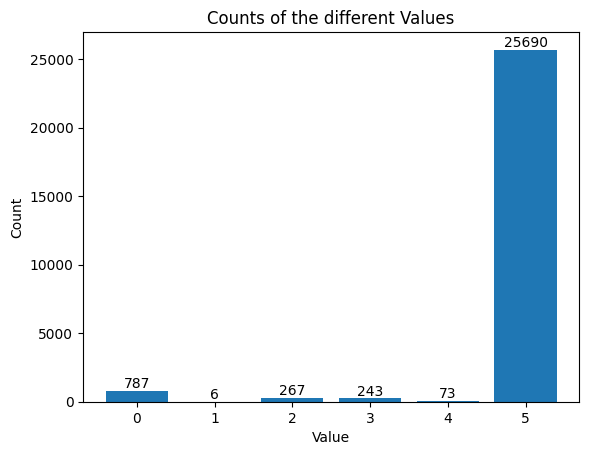

Validation set class distribution:


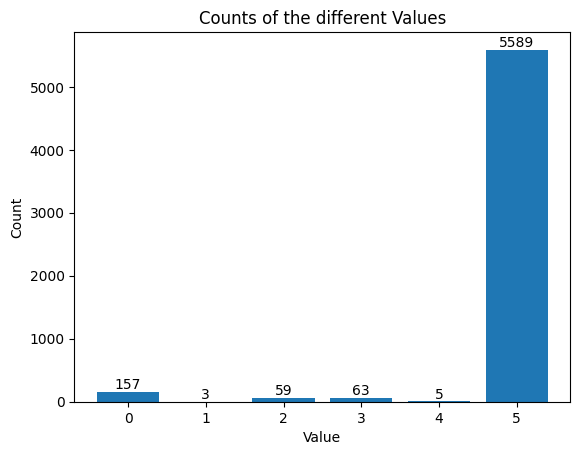

Test set class distribution:


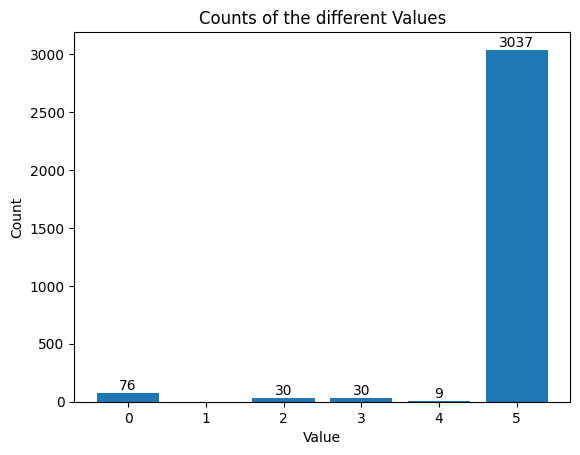

In [10]:
print("################## Training Set ##################")
X_train = []
y_train = []
i = 0
for run in train_runs:
    X_run, y_run = create_dataset(run, window_size=WINDOW_SIZE, step_size=STEP_SIZE)
    if X_run is not None and y_run is not None:
        if len(X_train) == 0:
            X_train = X_run
            y_train = y_run
            i += 1
            print("-------------------------------------------")
            continue
        X_train = np.vstack((X_train, X_run))
        y_train = np.hstack((y_train, y_run))
        i += 1
    print("-------------------------------------------")
X_train_scaled, scaler = scale_features(X_train)
print(f"{i} runs out of {len(train_runs)} processed for training set.")
i = 0

print("\n\n################## Validation Set ##################")

X_val = []
y_val = []
for run in val_runs:
    X_run, y_run = create_dataset(run, window_size=WINDOW_SIZE, step_size=STEP_SIZE)
    if X_run is not None and y_run is not None:
        if len(X_val) == 0:
            X_val = X_run
            y_val = y_run
            i += 1
            print("-------------------------------------------")
            continue
        X_val = np.vstack((X_val, X_run))
        y_val = np.hstack((y_val, y_run))
        i += 1
    print("-------------------------------------------")
X_val_scaled, _ = scale_features(X_val, scaler)
print(f"{i} runs out of {len(val_runs)} processed for validation set.")
i = 0

print("\n\n################## Test Set ##################")

X_test = []
y_test = []
for run in test_runs:
    X_run, y_run = create_dataset(run, window_size=WINDOW_SIZE, step_size=STEP_SIZE)
    if X_run is not None and y_run is not None:
        if len(X_test) == 0:
            X_test = X_run
            y_test = y_run
            i += 1
            print("-------------------------------------------")
            continue
        X_test = np.vstack((X_test, X_run))
        y_test = np.hstack((y_test, y_run))
        i += 1
    print("-------------------------------------------")
X_test_scaled, _ = scale_features(X_test, scaler)
print(f"{i} runs out of {len(test_runs)} processed for test set.")
i = 0

print(f"Final shapes - X_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"Final shapes - X_val: {X_val_scaled.shape}, y_val: {y_val.shape}")
print(f"Final shapes - X_test: {X_test_scaled.shape}, y_test: {y_test.shape}")
print("\n\nSaving datasets to datasets_output...")
np.savez(OUTPUT_DIR + "/train_dataset.npz", X=X_train_scaled, y=y_train)
np.savez(OUTPUT_DIR + "/val_dataset.npz", X=X_val_scaled, y=y_val)
np.savez(OUTPUT_DIR + "/test_dataset.npz", X=X_test_scaled, y=y_test)
print("Datasets saved.")

print("Training set class distribution:")
plot_counts(y_train)
print("Validation set class distribution:")
plot_counts(y_val)
print("Test set class distribution:")
plot_counts(y_test)

### Data Augmentation

Hier wird der eben erstelle Datensatz augmentiert. Der Grund dafür ist dass sehr viele Fenster der Klasse 5 vorhanden sind während die anderen Klassen stark unterrepräsentiert sind. Die Augmentation Logik ist in dataset_augmentor.py implementiert. Es sind vorherst nur ein paar Augmentation Techinken implementiert, diese können aber später noch erweitert werden um die anzahl der Daten zu Erhöhen.

Shape of augmented X_train: (9632, 120, 27), Shape of augmented y_train: (9632,)
Shape of augmented X_val: (2009, 120, 27), Shape of augmented y_val: (2009,)


Shape of final X_train: (36698, 120, 27), Shape of final y_train: (36698,)
Shape of final X_val: (7885, 120, 27), Shape of final y_val: (7885,)


Saving datasets to datasets_output...


Augmented datasets saved.
Training set class distribution (multiclass-augmented):


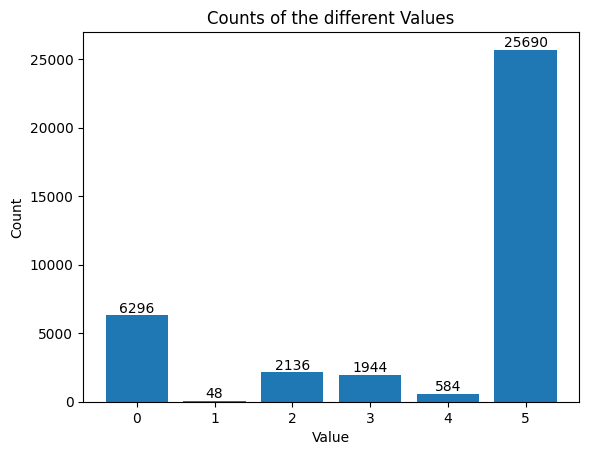

Validation set class distribution (multiclass-augmented):


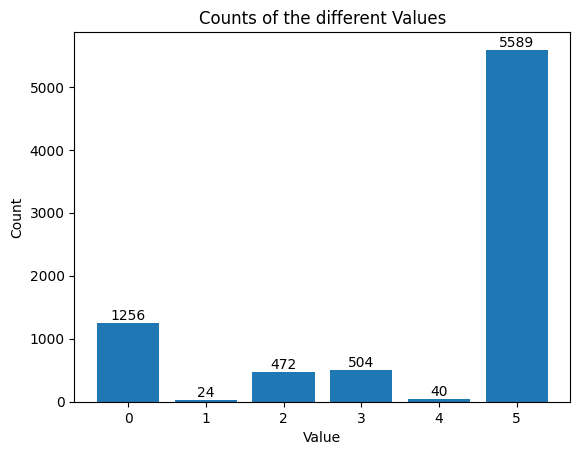

In [11]:
# augment  data as it is defined in dataset_augmentor.py
X_augmented, y_augmented = augment_data(X_train, y_train, nothing_label=CLASS_LABELS["Nothing"])
print(f"Shape of augmented X_train: {X_augmented.shape}, Shape of augmented y_train: {y_augmented.shape}")
X_val_augmented, y_val_augmented = augment_data(X_val, y_val, nothing_label=CLASS_LABELS["Nothing"])
print(f"Shape of augmented X_val: {X_val_augmented.shape}, Shape of augmented y_val: {y_val_augmented.shape}")


# Combine original and augmented data and scale it using the same scaler as the original training data to ensure consistency
X_train_final = np.vstack((X_train, X_augmented))
y_train_final = np.hstack((y_train, y_augmented))
X_train_final, _ = scale_features(X_train_final, scaler)
X_val_final = np.vstack((X_val, X_val_augmented))
y_val_final = np.hstack((y_val, y_val_augmented))
X_val_final, _ = scale_features(X_val_final, scaler)

# Shuffle augmented dataset. Using sklearn shuffle to shuffle X and y the same way
X_train_final, y_train_final = shuffle(X_train_final, y_train_final, random_state=SEED)
X_val_final, y_val_final = shuffle(X_val_final, y_val_final, random_state=SEED)

#Save augmented dataset
print(f"Shape of final X_train: {X_train_final.shape}, Shape of final y_train: {y_train_final.shape}")
print(f"Shape of final X_val: {X_val_final.shape}, Shape of final y_val: {y_val_final.shape}")
print("\n\nSaving datasets to datasets_output...")
np.savez(OUTPUT_DIR + "/train_dataset_augmented.npz", X=X_train_final, y=y_train_final)
np.savez(OUTPUT_DIR + "/val_dataset_augmented.npz", X=X_val_final, y=y_val_final)
print("Augmented datasets saved.")

print("Training set class distribution (multiclass-augmented):")
plot_counts(y_train_final)
print("Validation set class distribution (multiclass-augmented):")
plot_counts(y_val_final)




### Kombination von Labels
Um dem Problem der Class Imbalance entgegenzuwirken werden hier mehrere Labels zu einer Klasse zusammengefasst damit die daraus entstehende Klasse etwas größer ist.



Saving datasets to datasets_output...


Augmented binary datasets saved.
Training set class distribution (binary-augmented):


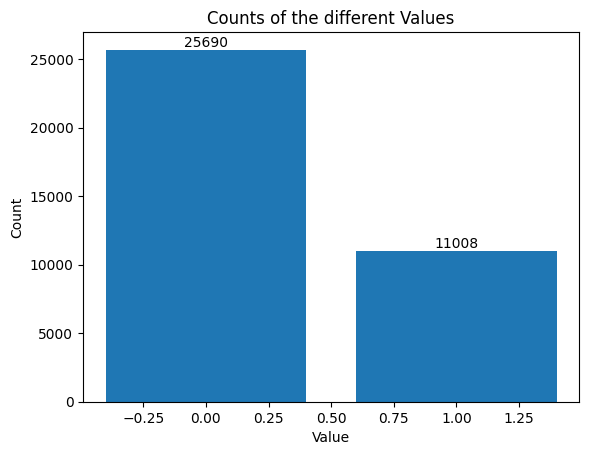

Validation set class distribution (binary-augmented):


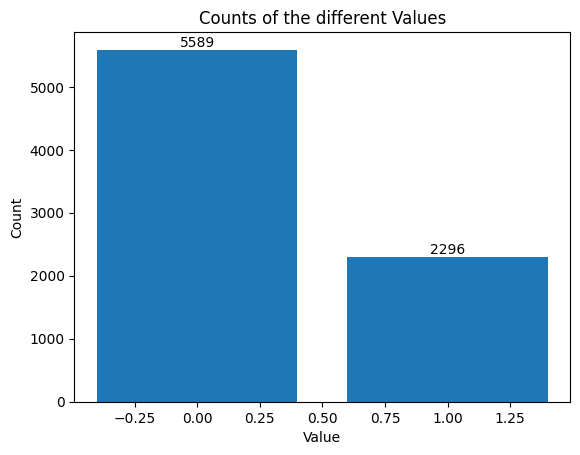

Binary Non-augmented training dataset saved.
Training set class distribution (binary-non-augmented):


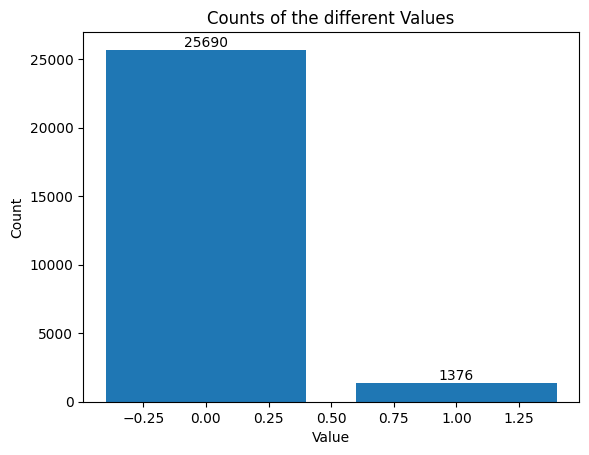

Binary Non-augmented Validation dataset saved.
Validation set class distribution (binary-non-augmented):


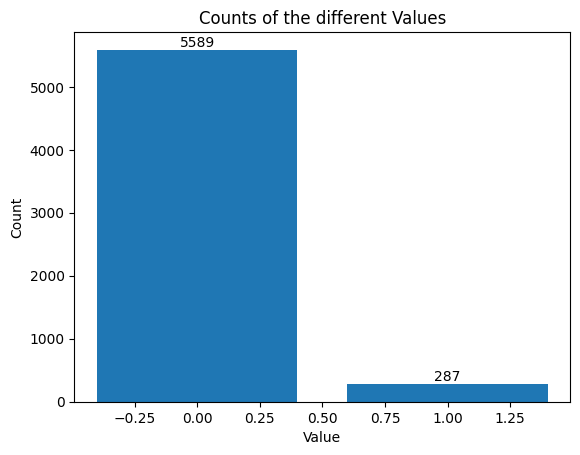

Binary Non-augmented Test dataset saved.
Test set class distribution (binary-non-augmented):


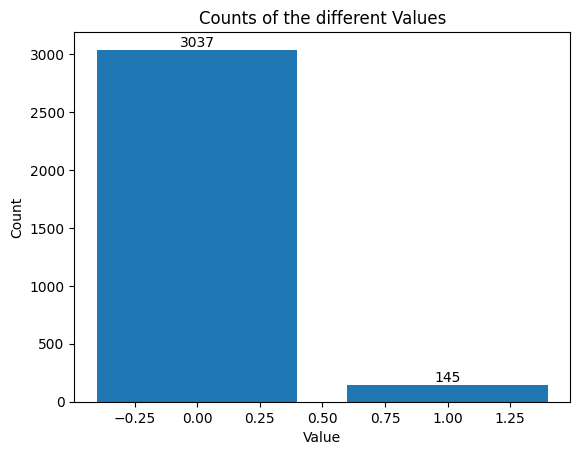

In [12]:
# convert augmented data to binary classification datasets
y_train_combined = y_train_final.copy()
y_val_combined = y_val_final.copy()

# set all labels that are not "Nothing" to "Action" for binary classification
y_train_combined[y_train_combined != CLASS_LABELS["Nothing"]] = 1
y_train_combined[y_train_combined == CLASS_LABELS["Nothing"]] = 0
y_val_combined[y_val_combined != CLASS_LABELS["Nothing"]] = 1
y_val_combined[y_val_combined == CLASS_LABELS["Nothing"]] = 0

#save augmentded binary datasets
print("\n\nSaving datasets to datasets_output...")
np.savez(OUTPUT_DIR + "/train_dataset_augmented_binary.npz", X=X_train_final, y=y_train_combined)
np.savez(OUTPUT_DIR + "/val_dataset_augmented_binary.npz", X=X_val_final, y=y_val_combined)
print("Augmented binary datasets saved.")

print("Training set class distribution (binary-augmented):")
plot_counts(y_train_combined)
print("Validation set class distribution (binary-augmented):")
plot_counts(y_val_combined)


#convert non augmented data to binary classification dataset
y_combined_non_augmented = y_train.copy()
y_combined_non_augmented[y_combined_non_augmented != CLASS_LABELS["Nothing"]] = 1
y_combined_non_augmented[y_combined_non_augmented == CLASS_LABELS["Nothing"]] = 0

np.savez(OUTPUT_DIR + "/train_dataset_binary.npz", X=X_train_scaled, y=y_combined_non_augmented)
print("Binary Non-augmented training dataset saved.")

print("Training set class distribution (binary-non-augmented):")
plot_counts(y_combined_non_augmented)

y_val_binary = y_val.copy()
y_val_binary[y_val_binary != CLASS_LABELS["Nothing"]] = 1
y_val_binary[y_val_binary == CLASS_LABELS["Nothing"]] = 0

np.savez(OUTPUT_DIR + "/val_dataset_binary.npz", X=X_val_scaled, y=y_val_binary)
print("Binary Non-augmented Validation dataset saved.")
print("Validation set class distribution (binary-non-augmented):")
plot_counts(y_val_binary)

y_test_binary = y_test.copy()
y_test_binary[y_test_binary != CLASS_LABELS["Nothing"]] = 1
y_test_binary[y_test_binary == CLASS_LABELS["Nothing"]] = 0

np.savez(OUTPUT_DIR + "/test_dataset_binary.npz", X=X_test_scaled, y=y_test_binary)
print("Binary Non-augmented Test dataset saved.")
print("Test set class distribution (binary-non-augmented):")
plot_counts(y_test_binary)
